In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
from functools import reduce
from sdv.evaluation.single_table import get_column_plot
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.utils import shuffle
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sdmetrics.reports.single_table import QualityReport
import joblib

In [7]:
root = Path.cwd().parent 

raw_fake = pd.read_csv(root / "Artificial Data" / "RAW.csv")
raw_real = pd.read_csv(root / "Real Data" / "RAW_REAL.csv")

reduced_fake = pd.read_csv(root / "Artificial Data" / "BackAndForth.csv")
reduced_real = pd.read_csv(root / "Real Data" / "BackAndForthREAL.csv")

engineered_fake = pd.read_csv(root / "Artificial Data" / "OverEngineered.csv")
engineered_real = pd.read_csv(root / "Real Data" / "OverEngineeredREAL.csv") 

In [8]:
df = pd.read_csv(root / "Real Data" / "log2.csv")
# Filter columns that contain 'port' (case-insensitive)
port_columns = [col for col in df.columns if 'port' in col.lower()]

# Print number of unique values for each 'port' column
for col in port_columns:
    unique_count = df[col].nunique(dropna=True)
    print(f"{col}: {unique_count} unique values")

Source Port: 22724 unique values
Destination Port: 3273 unique values
NAT Source Port: 29152 unique values
NAT Destination Port: 2533 unique values


In [7]:
def plot_kde_distributions_separate(dfs, labels, colors=None):
    """
    Plot KDEs for Bytes, Packets, and Elapsed Time (sec) as separate figures across multiple DataFrames.

    Parameters:
    - dfs: list of pandas DataFrames
    - labels: list of labels corresponding to each DataFrame
    - colors: optional list of colors for the KDE lines
    """
    assert len(dfs) == len(labels), "Each DataFrame must have a corresponding label."

    target_cols = [
        'Bytes',
        'Packets',
        'Elapsed Time (sec)'
    ]

    for col in target_cols:
        fig, ax = plt.subplots(figsize=(6, 4))
        for i, df in enumerate(dfs):
            if col in df.columns:
                try:
                    df[col].dropna().plot(kind='kde', ax=ax, label=labels[i], linewidth=2,
                                          linestyle='--' if i else '-', color=(colors[i] if colors else None))
                except:
                    pass
        ax.set_title(f'Distribution: {col}')
        ax.grid(True)
        ax.legend()
        plt.tight_layout()
        plt.show()

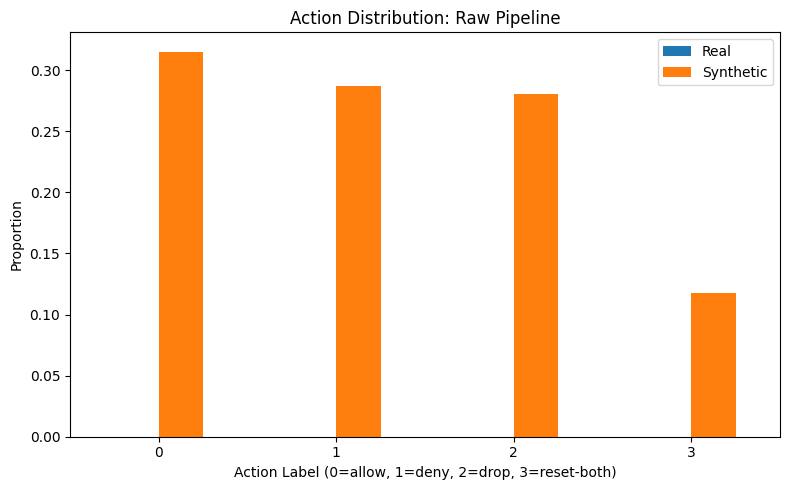

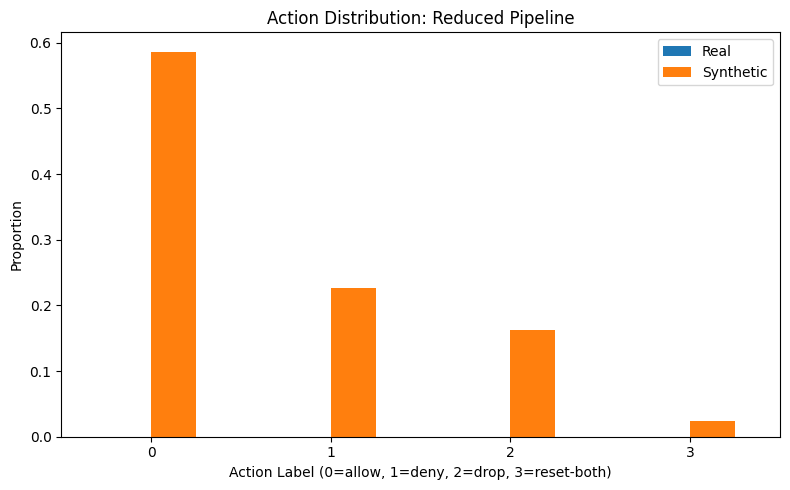

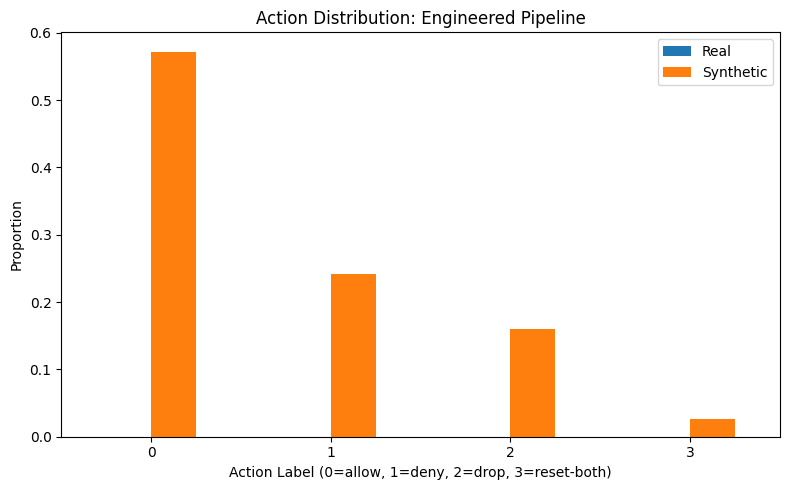

In [4]:
label_map = {'allow': 0, 'deny': 1, 'drop': 2, 'reset-both': 3}
real_df['Action'] = real_df['Action'].map(label_map)

synthetic_datasets = {
    'Raw': pd.read_csv(root / "Artificial Data" / "RAW.csv"),
    'Reduced': pd.read_csv(root / "Artificial Data" / "BackAndForth.csv"),
    'Engineered': pd.read_csv(root / "Artificial Data" / "OverEngineered.csv")
}

for name, synth_df in synthetic_datasets.items():
    if name == 'Raw':
        synth_df['Action'] = synth_df['Action'].map(label_map)
    # If already int in Reduced/Engineered → keep as-is
    
    real_actions = real_df['Action'].dropna()
    synth_actions = synth_df['Action'].dropna()

    if synth_actions.empty:
        print(f"⚠️ Skipping {name} pipeline — no valid Action labels after mapping.")
        continue

    real_dist = real_actions.value_counts(normalize=True)
    synth_dist = synth_actions.value_counts(normalize=True)

    all_labels = sorted(set(real_dist.index).union(synth_dist.index))

    comparison_df = pd.DataFrame({
        'Real': real_dist.reindex(all_labels, fill_value=0),
        'Synthetic': synth_dist.reindex(all_labels, fill_value=0)
    })

    comparison_df.plot(kind='bar', figsize=(8, 5), title=f"Action Distribution: {name} Pipeline")
    plt.xlabel("Action Label (0=allow, 1=deny, 2=drop, 3=reset-both)")
    plt.ylabel("Proportion")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


In [ ]:
real_dist = real_df['Action'].value_counts(normalize=True)
synthetic_dist = synth_df['Action'].value_counts(normalize=True)

comparison_df = pd.DataFrame({
    'Real': real_dist,
    'Synthetic': synthetic_dist
}).fillna(0)

comparison_df.plot(kind='bar', figsize=(8, 5), title="Action Label Distribution: Real vs Synthetic")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
def plot_kde_distributions_selected(dfs, labels, colors=None):
    """
    Plot KDEs for the exact list of traffic-related columns across multiple DataFrames.

    Parameters:
    - dfs: list of pandas DataFrames
    - labels: list of labels corresponding to each DataFrame
    - colors: optional list of colors for the KDE lines
    """
    assert len(dfs) == len(labels), "Each DataFrame must have a corresponding label."

    target_cols = [
        'Bytes', 'Bytes Sent', 'Bytes Received',
        'Packets', 'pkts_sent', 'pkts_received',
        'Elapsed Time (sec)', 'Source Port', 
        'Destination Port', 'NAT Source Port', 
        'NAT Destination Port'
    ]

    n = len(target_cols)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 5, nrows * 4))
    axes = axes.flatten()

    for idx, col in enumerate(target_cols):
        ax = axes[idx]
        for i, df in enumerate(dfs):
            if col in df.columns:
                try:
                    df[col].dropna().plot(kind='kde', ax=ax, label=labels[i], linewidth=2,
                                          linestyle='--' if i else '-', color=(colors[i] if colors else None))
                except:
                    pass
        ax.set_title(f'Distribution: {col}')
        ax.grid(True)
        ax.legend()

    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()



def ks_test_summary(real_df, synth_df, features):
    
    results = {}
    
    for col in features:
        if not np.issubdtype(real_df[col].dtype, np.number):
            continue
        stat, p = ks_2samp(real_df[col].dropna(), synth_df[col].dropna())
        results[col] = {'KS_stat': stat, 'p_value': p}
        
    return pd.DataFrame(results).T.sort_values('KS_stat', ascending=False)



def correlation_heatmaps_multi(dfs, labels, title="Correlation Comparison"):
    """
    Plot correlation heatmaps for multiple DataFrames (2 per row).
    Plots only selected numeric columns: Bytes, Bytes Sent, Bytes Received,
    Packets, pkts_sent, pkts_received, Elapsed Time (sec).
    
    Parameters:
    - dfs: list of pandas DataFrames
    - labels: list of labels corresponding to each DataFrame
    - title: overall figure title
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import math

    assert len(dfs) == len(labels), "Each DataFrame must have a corresponding label."

    target_features = [
        "Bytes", "Bytes Sent", "Bytes Received", 
        "Packets", "pkts_sent", "pkts_received", 
        "Elapsed Time (sec)", "Source Port", "Destination Port", "NAT Source Port", "Nat Destination Port"
    ]

    # Check which features are present in all DataFrames
    shared_cols = [col for col in target_features if all(col in df.columns for df in dfs)]

    if not shared_cols:
        raise ValueError("None of the target features are shared across all DataFrames.")

    # Grid layout: 2 plots per row
    n = len(dfs)
    ncols = 2
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 6, nrows * 6))
    axes = axes.flatten()

    for i, (df, label) in enumerate(zip(dfs, labels)):
        ax = axes[i]
        corr = df[shared_cols].corr()
        sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax, annot=False, square=True)
        ax.set_title(f"{label} Correlation")

    # Remove unused axes if any
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()




def run_tsne_visualization(df, synth_df, sample_size=2000, title="t-SNE Visualization Real VS Fake"):
    
    X_real = df.drop(columns=['Attack'], errors='ignore').select_dtypes(include='number')    
    X_synth = synth_df.drop(columns=['Attack'], errors='ignore').select_dtypes(include='number')
    
    if 'Flow Duration' in X_synth.columns:
        X_synth = X_synth[X_synth['Flow Duration'] > 0]
        
    X_real['__index'] = range(len(X_real))
    X_synth['__index'] = range(len(X_synth))
    
    labels = pd.Series(['Real'] * len(X_real) + ['Synthetic'] * len(X_synth))
    
    X_combined = pd.concat([X_real, X_synth], ignore_index=True)
    X_combined = X_combined.drop(columns=['__index'], errors='ignore')
    X_combined = X_combined.apply(pd.to_numeric, errors='coerce')
    X_combined = X_combined.replace([np.inf, -np.inf], np.nan)
    
    imputer = SimpleImputer(strategy='mean')
    X_imputed = pd.DataFrame(imputer.fit_transform(X_combined), columns=X_combined.columns)
    X_real_clean = X_imputed[labels == 'Real']
    X_synth_clean = X_imputed[labels == 'Synthetic']
    
    n = min(sample_size, len(X_real_clean), len(X_synth_clean))
    X_real_sample = X_real_clean.sample(n=n, random_state=42)
    X_synth_sample = X_synth_clean.sample(n=n, random_state=42)
    X_final = pd.concat([X_real_sample, X_synth_sample], ignore_index=True)
    final_labels = ['Real'] * n + ['Synthetic'] * n
    X_scaled = StandardScaler().fit_transform(X_final)
    
    tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
    X_embedded = tsne.fit_transform(X_scaled)
    
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=X_embedded[:, 0], y=X_embedded[:, 1], hue=final_labels, alpha=0.6, palette='Set2')
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()



def tstr_rf_per_action(real_df: pd.DataFrame, synth_df: pd.DataFrame, label="TSTR"):

    # Train a Random Forest classifier to distinguish real vs synthetic data within each Action class.
    # A high score means synthetic data is distinguishable; low = better fidelity.

    real_df, synth_df = real_df.align(synth_df, join='inner', axis=1)

    cat_cols = real_df.select_dtypes(include=["object", "category"]).columns
    for col in cat_cols:
        le = LabelEncoder()
        combined_vals = pd.concat([real_df[col], synth_df[col]], axis=0).astype(str)
        le.fit(combined_vals)

        real_df[col] = le.transform(real_df[col].astype(str))
        synth_df[col] = le.transform(synth_df[col].astype(str))

    if "Action" not in real_df.columns:
        print(f"[{label}] 'Action' column missing, skipping...")
        return {}

    results = {}
    for action_val in sorted(real_df['Action'].dropna().unique()):
        real_subset = real_df[real_df['Action'] == action_val].copy()
        synth_subset = synth_df[synth_df['Action'] == action_val].copy()

        if len(real_subset) < 10 or len(synth_subset) < 10:
            continue

        real_subset['__label__'] = 0
        synth_subset['__label__'] = 1

        combined = pd.concat([real_subset, synth_subset])
        combined = shuffle(combined, random_state=42)

        X = combined.drop(columns="__label__")
        y = combined["__label__"]

        clf = RandomForestClassifier(n_estimators=100, random_state=42)
        scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')

        results[int(action_val)] = (scores.mean(), scores.std())
        print(f"{label} [Action={int(action_val)}] - Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

    return results



def train_on_synthetic_test_on_real_rf(real_df, synth_df):

    # Train on synthetic data, test on real data using Random Forest for Attack classification.
    # Measures the utility of synthetic data for downstream prediction tasks.

    if 'Action' not in real_df.columns or 'Action' not in synth_df.columns:
        raise ValueError("Both datasets must contain an 'Action' column to derive the 'Attack' label.")

    real_df = real_df.copy()
    synth_df = synth_df.copy()

    real_df['Attack'] = (real_df['Action'] != 0).astype(int)
    synth_df['Attack'] = (synth_df['Action'] != 0).astype(int)

    real_df, synth_df = real_df.align(synth_df, join='inner', axis=1)

    target_col = 'Attack'
    X_synth = synth_df.drop(columns=target_col)
    y_synth = synth_df[target_col]

    X_real = real_df.drop(columns=target_col)
    y_real = real_df[target_col]

    for col in X_synth.select_dtypes(include=['object', 'category']).columns:
        le = LabelEncoder()
        combined_vals = pd.concat([X_synth[col], X_real[col]], axis=0).astype(str)
        le.fit(combined_vals)

        X_synth[col] = le.transform(X_synth[col].astype(str))
        X_real[col] = le.transform(X_real[col].astype(str))

    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_synth, y_synth)

    # Evaluate on real
    y_pred = clf.predict(X_real)
    acc = accuracy_score(y_real, y_pred)
    f1 = f1_score(y_real, y_pred, average='macro')

    print(f"TSTR RF - Accuracy: {acc:.4f}, F1 (macro): {f1:.4f}")
    return acc, f1



def compare_tstr_models_on_attack(real_df, synth_df):

    # Compare multiple models (RF, LR, SVC, MLP) trained on synthetic and tested on real
    # for Attack prediction, with internal handling of Action-to-Attack label conversion and encoding.
    
    action_mapping = {'allow': 0, 'deny': 1, 'drop': 2, 'reset-both': 3}
    real_df = real_df.copy()
    synth_df = synth_df.copy()

    if real_df['Action'].dtype == 'object' or pd.api.types.is_string_dtype(real_df['Action']):
        real_df['Action'] = real_df['Action'].map(action_mapping)
    if synth_df['Action'].dtype == 'object' or pd.api.types.is_string_dtype(synth_df['Action']):
        synth_df['Action'] = synth_df['Action'].map(action_mapping)

    real_df['Attack'] = (real_df['Action'] != 0).astype(int)
    synth_df['Attack'] = (synth_df['Action'] != 0).astype(int)

    real_df, synth_df = real_df.align(synth_df, join='inner', axis=1)

    target_col = 'Attack'
    X_synth = synth_df.drop(columns=target_col)
    y_synth = synth_df[target_col]
    X_real = real_df.drop(columns=target_col)
    y_real = real_df[target_col]

    for col in X_synth.columns:
        if not pd.api.types.is_numeric_dtype(X_synth[col]):
            le = LabelEncoder()
            combined = pd.concat([X_synth[col], X_real[col]], axis=0).astype(str)
            le.fit(combined)

            X_synth[col] = X_synth[col].astype(str).map(lambda x: le.transform([x])[0] if x in le.classes_ else -1)
            X_real[col] = X_real[col].astype(str).map(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

    X_synth.fillna(-1, inplace=True)
    X_real.fillna(-1, inplace=True)

    classifiers = {
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Support Vector Classifier': SVC(random_state=42),
        'MLP Neural Net': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
    }

    results = {}
    for name, clf in classifiers.items():
        clf.fit(X_synth, y_synth)
        y_pred = clf.predict(X_real)
        acc = accuracy_score(y_real, y_pred)
        f1 = f1_score(y_real, y_pred, average='macro')
        results[name] = (acc, f1)
        print(f"{name}: Accuracy = {acc:.4f}, F1 (macro) = {f1:.4f}")

    return results



def baseline_train_test_same_source(df, action_col="Action"):

    # Train and test on real data using Random Forest to measure
    # how learnable the Attack label is using existing features (baseline utility).
    
    df = df.copy()

    if df[action_col].dtype == 'object' or pd.api.types.is_string_dtype(df[action_col]):
        action_mapping = {'allow': 0, 'deny': 1, 'drop': 2, 'reset-both': 3}
        df[action_col] = df[action_col].map(action_mapping)
    df["Attack"] = (df[action_col] != 0).astype(int)

    for col in df.columns:
        if col == "Attack":
            continue
        if not pd.api.types.is_numeric_dtype(df[col]):
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))

    X = df.drop(columns=["Attack"])
    y = df["Attack"]

    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X, y)
    y_pred = clf.predict(X)

    acc = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred, average='macro')
    print(f"Train-on-Real → Test-on-Real: Accuracy = {acc:.4f}, F1 (macro) = {f1:.4f}")
    return acc, f1



def filter_synthetic_by_rf_confidence(real_df, synth_df, drop_top_pct=0.25, random_state=42):
    
    excluded_cols = ['Unnamed: 0', '__label__', 'Attack']
    numeric_cols = real_df.select_dtypes(include='number').columns.difference(excluded_cols)

    real_labeled = real_df.copy()
    synth_labeled = synth_df.copy()
    real_labeled['__label__'] = 0
    synth_labeled['__label__'] = 1
    combined = pd.concat([real_labeled, synth_labeled], ignore_index=True)

    features = list(numeric_cols)
    X = combined[features]
    y = combined['__label__']

    rf = RandomForestClassifier(n_estimators=100, random_state=random_state)
    rf.fit(X, y)
    combined['rf_synth_proba'] = rf.predict_proba(X)[:, 1]

    synth_only = combined[combined['__label__'] == 1]
    threshold = synth_only['rf_synth_proba'].quantile(1 - drop_top_pct)
    filtered_synth = synth_only[synth_only['rf_synth_proba'] < threshold].drop(columns=['__label__', 'rf_synth_proba'])

    dropped = synth_df.shape[0] - filtered_synth.shape[0]
    return filtered_synth, dropped


    # Removes the most anomalous synthetic samples using Isolation Forest.
    # Outliers are defined relative to the combined distribution of real + synthetic data.

def filter_synthetic_by_isolation_forest(real_df, synth_df, contamination=0.1, random_state=42):

    common_numeric_cols = real_df.select_dtypes(include='number').columns.intersection(
        synth_df.select_dtypes(include='number').columns
    )

    df_combined = pd.concat([
        real_df[common_numeric_cols].assign(source='real'),
        synth_df[common_numeric_cols].assign(source='synthetic')
    ], ignore_index=True)

    scaler = StandardScaler()
    X_combined = scaler.fit_transform(df_combined[common_numeric_cols])

    iso = IsolationForest(n_estimators=100, contamination=contamination, random_state=random_state)
    iso.fit(X_combined)

    df_combined['anomaly_score'] = iso.decision_function(X_combined)
    df_combined['outlier_flag'] = iso.predict(X_combined)  # -1 = outlier

    synth_clean = df_combined[
        (df_combined['source'] == 'synthetic') &
        (df_combined['outlier_flag'] != -1)
    ].drop(columns=['source', 'anomaly_score', 'outlier_flag'])

    dropped = synth_df.shape[0] - synth_clean.shape[0]
    return synth_clean, dropped

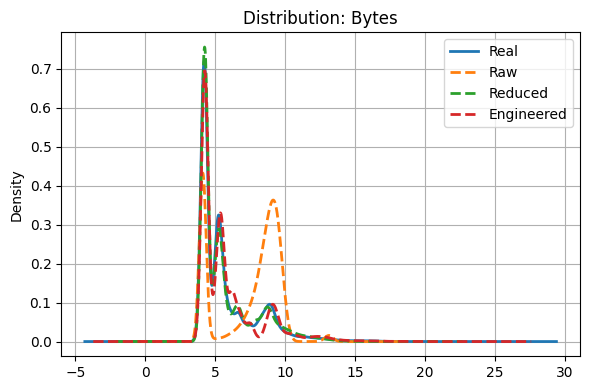

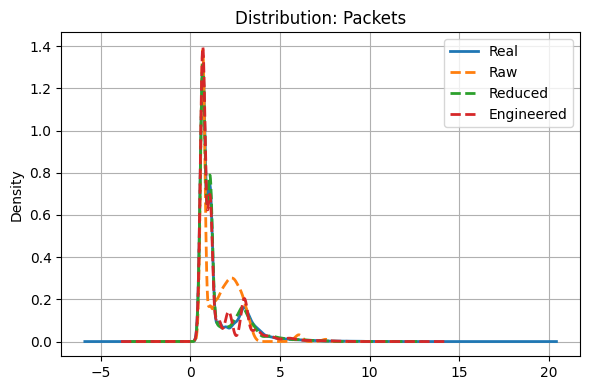

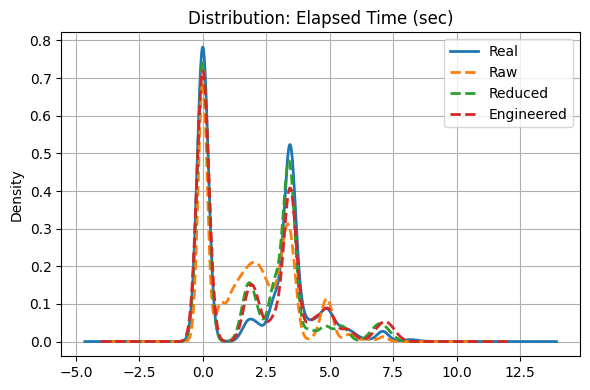

In [11]:
plot_kde_distributions_separate(
    dfs=[raw_real, raw_fake, reduced_fake, engineered_fake],
    labels=['Real', 'Raw', 'Reduced', 'Engineered']
)

In [9]:
pairs = {
    "raw": (raw_real, raw_fake),
    "reduced": (reduced_real, reduced_fake),
    "engineered": (engineered_real, engineered_fake)
}

summary_frames = []

for label, (real_df, fake_df) in pairs.items():
    numerical_cols = real_df.select_dtypes(include=[np.number]).columns.difference([
        'Source Port', 'Destination Port', 'NAT Source Port', 'NAT Destination Port',
        'Action', 'Unnamed: 0', 'Bytes_log', 'Packets_log'
    ]).tolist()

    summary = ks_test_summary(real_df, fake_df, features=numerical_cols)
    summary = summary.rename(columns={
        'KS_stat': f'KS_stat_{label}',
        'p_value': f'p_value_{label}'
    })
    summary_frames.append(summary)

from functools import reduce
ks_summary_full = reduce(
    lambda left, right: pd.merge(left, right, left_index=True, right_index=True),
    summary_frames
)

print(ks_summary_full)

                    KS_stat_raw  p_value_raw  KS_stat_reduced  \
Bytes Sent             0.549243          0.0         0.116810   
pkts_log               0.484252          0.0         0.065349   
Bytes                  0.470106          0.0         0.096257   
Bytes Received         0.390588          0.0         0.112367   
Bytes Ratio            0.352561          0.0         0.199650   
pkts_received          0.351523          0.0         0.111912   
pkts_ratio             0.306766          0.0         0.158597   
pkts_sent              0.284807          0.0         0.078398   
Elapsed Time (sec)     0.242981          0.0         0.185604   
Packets                0.235564          0.0         0.065349   

                    p_value_reduced  KS_stat_engineered  p_value_engineered  
Bytes Sent             0.000000e+00            0.095452       3.966927e-227  
pkts_log              1.418375e-106            0.198321        0.000000e+00  
Bytes                 5.657431e-231            0.1

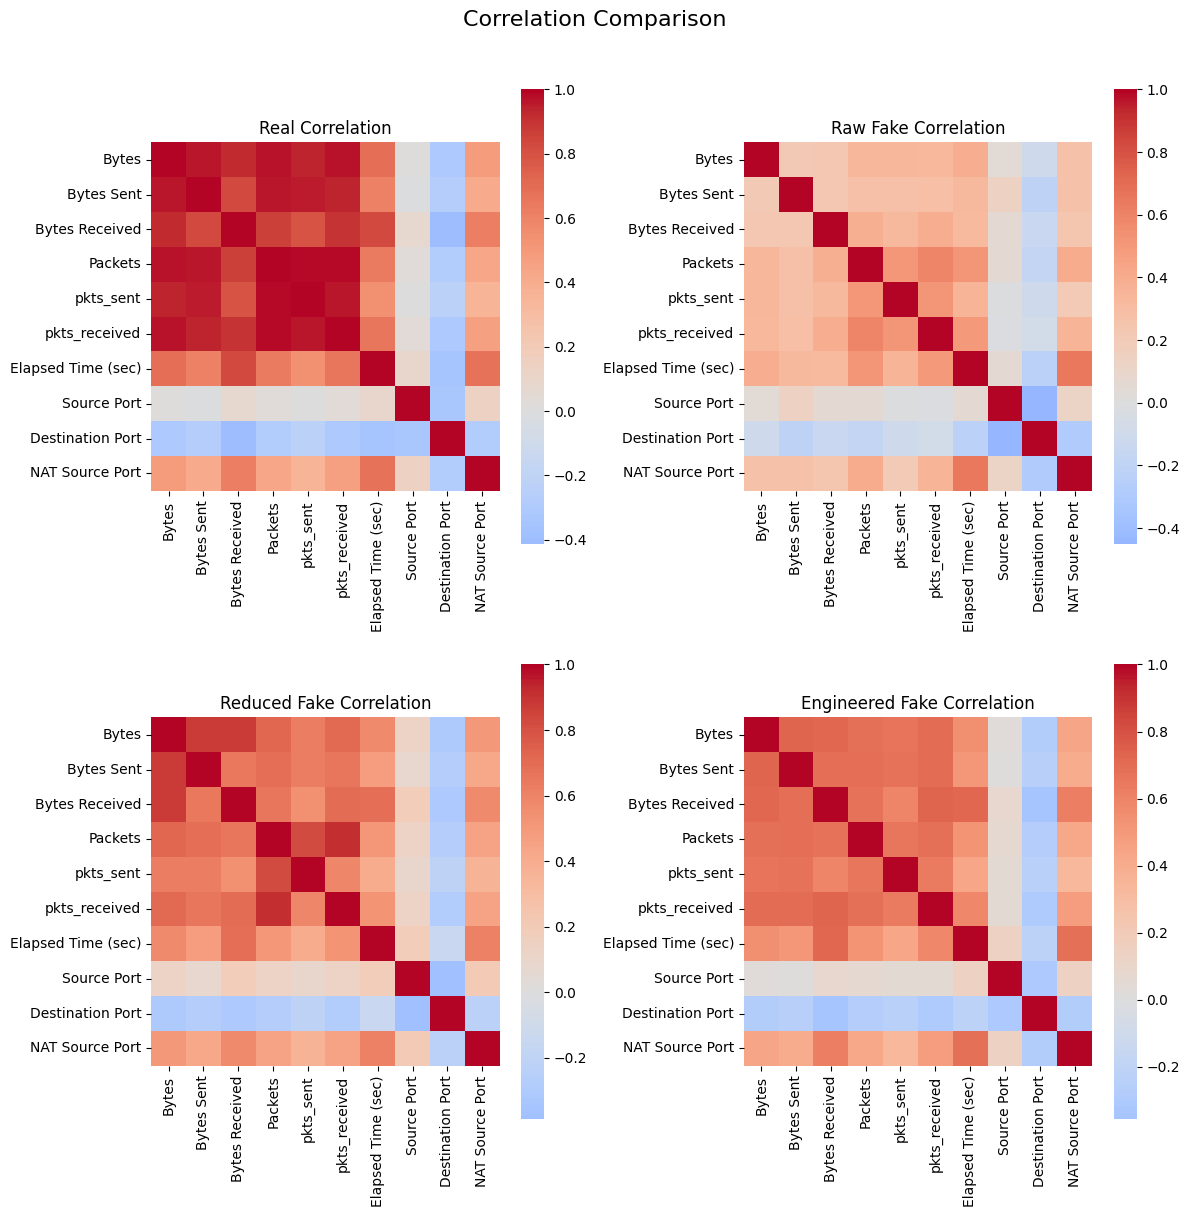

In [12]:
correlation_heatmaps_multi(
    dfs=[raw_real, raw_fake, reduced_fake, engineered_fake],
    labels=['Real', 'Raw Fake', 'Reduced Fake', 'Engineered Fake']
)

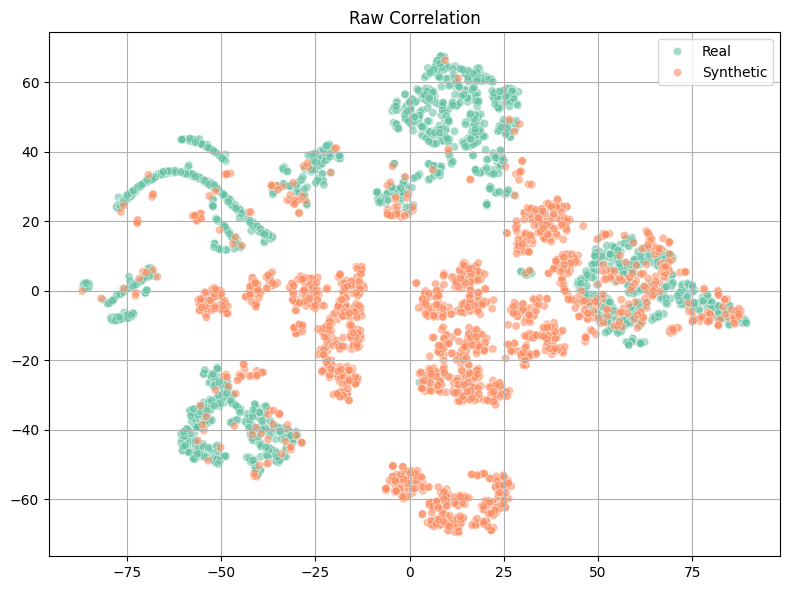

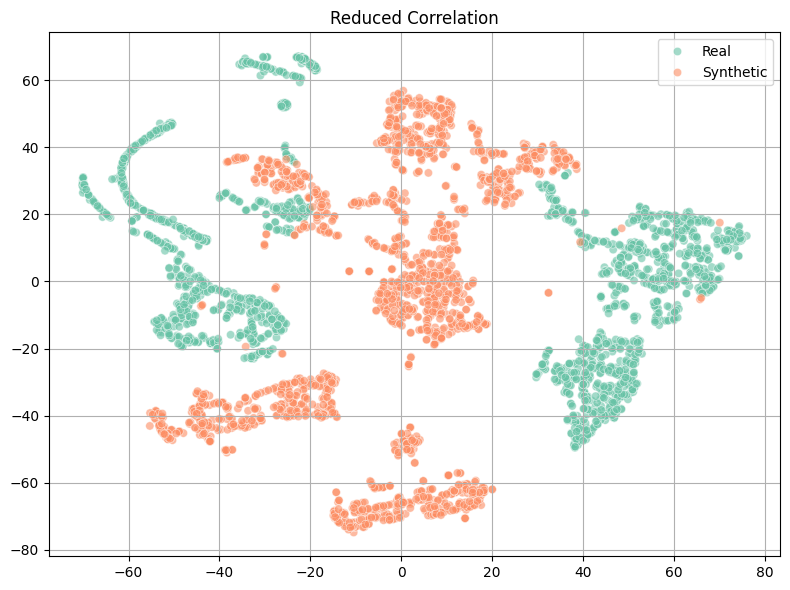

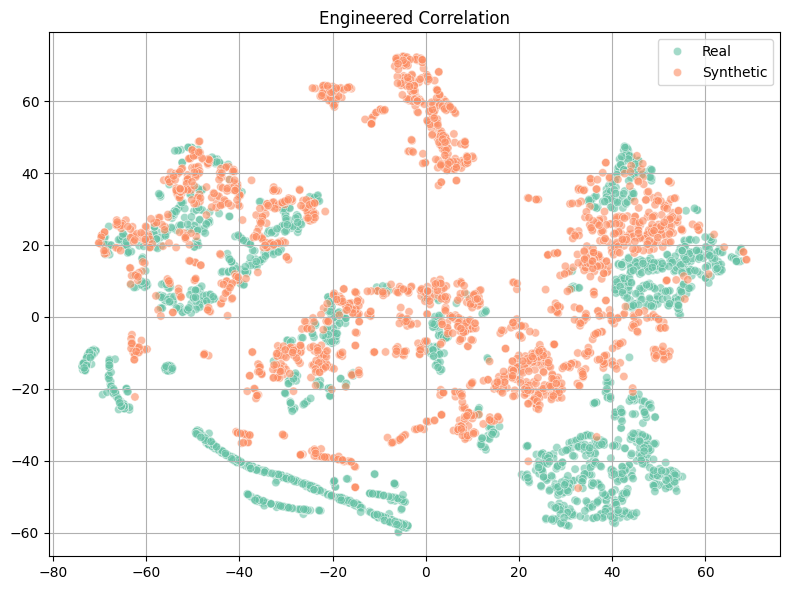

In [69]:
reduced_fake.drop('Bytes_log', axis=1, inplace=True)
reduced_real.drop('Bytes_log', axis=1, inplace=True)

run_tsne_visualization(raw_real, raw_fake, title="Raw Correlation")
run_tsne_visualization(reduced_real, reduced_fake, title="Reduced Correlation")
run_tsne_visualization(engineered_real, engineered_fake, title="Engineered Correlation")

In [71]:
tstr_rf_per_action(raw_real, raw_fake, label="Raw")
tstr_rf_per_action(reduced_real, reduced_fake, label="Reduced")
tstr_rf_per_action(engineered_real, engineered_fake, label="Engineered")

Raw [Action=0] - Accuracy: 0.9995 ± 0.0001
Raw [Action=1] - Accuracy: 0.9984 ± 0.0002
Raw [Action=2] - Accuracy: 1.0000 ± 0.0001
Raw [Action=3] - Accuracy: 0.9999 ± 0.0003
Reduced [Action=0] - Accuracy: 1.0000 ± 0.0000
Reduced [Action=1] - Accuracy: 1.0000 ± 0.0000
Reduced [Action=2] - Accuracy: 1.0000 ± 0.0000
Reduced [Action=3] - Accuracy: 1.0000 ± 0.0000
Engineered [Action=0] - Accuracy: 0.9997 ± 0.0001
Engineered [Action=1] - Accuracy: 1.0000 ± 0.0001
Engineered [Action=2] - Accuracy: 1.0000 ± 0.0000
Engineered [Action=3] - Accuracy: 1.0000 ± 0.0000


{0: (0.9996721372434006, 8.552389372650913e-05),
 1: (0.9999542648067689, 9.147038646237781e-05),
 2: (1.0, 0.0),
 3: (1.0, 0.0)}

In [72]:
compare_tstr_models_on_attack(raw_real, raw_fake)
compare_tstr_models_on_attack(reduced_real, reduced_fake)
compare_tstr_models_on_attack(engineered_real, engineered_fake)

Random Forest: Accuracy = 1.0000, F1 (macro) = 1.0000


C:\Users\Карен Оганян\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression: Accuracy = 0.9959, F1 (macro) = 0.9958
Support Vector Classifier: Accuracy = 0.9485, F1 (macro) = 0.9480
MLP Neural Net: Accuracy = 0.9919, F1 (macro) = 0.9917
Random Forest: Accuracy = 1.0000, F1 (macro) = 1.0000


C:\Users\Карен Оганян\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression: Accuracy = 0.9999, F1 (macro) = 0.9999
Support Vector Classifier: Accuracy = 0.9685, F1 (macro) = 0.9659
MLP Neural Net: Accuracy = 0.9932, F1 (macro) = 0.9925
Random Forest: Accuracy = 1.0000, F1 (macro) = 1.0000


C:\Users\Карен Оганян\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression: Accuracy = 0.9996, F1 (macro) = 0.9996
Support Vector Classifier: Accuracy = 0.9595, F1 (macro) = 0.9563
MLP Neural Net: Accuracy = 0.9903, F1 (macro) = 0.9893


{'Random Forest': (1.0, 1.0),
 'Logistic Regression': (0.999597691096729, 0.9995551198062741),
 'Support Vector Classifier': (0.9595242259926535, 0.9563388090186211),
 'MLP Neural Net': (0.9902571278642645, 0.9892915701796019)}

In [73]:
baseline_train_test_same_source(raw_real)
baseline_train_test_same_source(reduced_real)
baseline_train_test_same_source(engineered_real)

Train-on-Real → Test-on-Real: Accuracy = 1.0000, F1 (macro) = 1.0000
Train-on-Real → Test-on-Real: Accuracy = 1.0000, F1 (macro) = 1.0000
Train-on-Real → Test-on-Real: Accuracy = 1.0000, F1 (macro) = 1.0000


(1.0, 1.0)

In [74]:
filtered_synth_df, n_dropped = filter_synthetic_by_rf_confidence(real_df=raw_real, synth_df=raw_fake)
print(f"Raw Datasets:\nDropped {n_dropped} rows ({n_dropped / raw_real.shape[0]:.2%})")

filtered_synth_df, n_dropped = filter_synthetic_by_rf_confidence(real_df=reduced_real, synth_df=reduced_fake)
print(f"Reduced Datasets:\nDropped {n_dropped} rows ({n_dropped / reduced_real.shape[0]:.2%})")

filtered_synth_df, n_dropped = filter_synthetic_by_rf_confidence(real_df=engineered_real, synth_df=engineered_fake)
print(f"OverEngineered Datasets:\nDropped {n_dropped} rows ({n_dropped / engineered_real.shape[0]:.2%})")

Raw Datasets:
Dropped 60405 rows (92.18%)
Reduced Datasets:
Dropped 56649 rows (99.09%)
OverEngineered Datasets:
Dropped 53541 rows (93.65%)


In [75]:
filtered_synth_if, n_dropped_if = filter_synthetic_by_isolation_forest(real_df=raw_real, synth_df=raw_fake)
print(f"Raw Datasets:\nDropped {n_dropped_if} synthetic rows ({n_dropped_if / raw_real.shape[0]:.2%})")

filtered_synth_if, n_dropped_if = filter_synthetic_by_isolation_forest(real_df=reduced_real, synth_df=reduced_fake)
print(f"Reduced Datasets:\nDropped {n_dropped_if} synthetic rows ({n_dropped_if / reduced_real.shape[0]:.2%})")

filtered_synth_if, n_dropped_if = filter_synthetic_by_isolation_forest(real_df=engineered_real, synth_df=engineered_fake)
print(f"OverEngineered Datasets:\nDropped {n_dropped_if} synthetic rows ({n_dropped_if / engineered_real.shape[0]:.2%})")

Raw Datasets:
Dropped 7967 synthetic rows (12.16%)
Reduced Datasets:
Dropped 7479 synthetic rows (13.08%)
OverEngineered Datasets:
Dropped 7696 synthetic rows (13.46%)
